# 02 - Training
## Objectif : Entraîner les modèles avec les vraies valeurs contemporaines
## ⚠️ Vraies valeurs en Train/Test → Moyenne en prédiction future

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Imports OK')

✅ Imports OK


## 1. Charger dataset + features

In [30]:
df_ml = pd.read_csv('/app/notebooks/ml_dataset.csv', parse_dates=['date'])

with open('/app/notebooks/selected_features.json') as f:
    FEATURES = json.load(f)

# Variables contemporaines à inclure avec leurs vraies valeurs
CONTEMPORAINES = ['nb_clients', 'nb_documents', 'total_quantity']
CONTEMPORAINES = [c for c in CONTEMPORAINES if c in df_ml.columns]

# Features finales = features sélectionnées + contemporaines
FEATURES_FINAL = list(set(FEATURES + CONTEMPORAINES))
FEATURES_FINAL = [f for f in FEATURES_FINAL if f in df_ml.columns]

TARGET = 'total_sales'

print(f'✅ Dataset      : {df_ml.shape}')
print(f'✅ Période      : {df_ml["date"].min().strftime("%b %Y")} → {df_ml["date"].max().strftime("%b %Y")}')
print(f'✅ Features sélectionnées ({len(FEATURES)}) : {FEATURES}')
print(f'✅ Contemporaines ajoutées  ({len(CONTEMPORAINES)}) : {CONTEMPORAINES}')
print(f'✅ FEATURES_FINAL ({len(FEATURES_FINAL)}) : {FEATURES_FINAL}')

✅ Dataset      : (43, 18)
✅ Période      : Jul 2022 → Jan 2026
✅ Features sélectionnées (6) : ['lag_1', 'rolling_mean_3', 'lag_2', 'nb_documents', 'nb_clients', 'total_quantity']
✅ Contemporaines ajoutées  (3) : ['nb_clients', 'nb_documents', 'total_quantity']
✅ FEATURES_FINAL (6) : ['lag_2', 'lag_1', 'rolling_mean_3', 'nb_clients', 'total_quantity', 'nb_documents']


## 2. Split temporel 85/15

Train : 36 mois (Jul 2022 → Jun 2025)
Test  : 7 mois (Jul 2025 → Jan 2026)


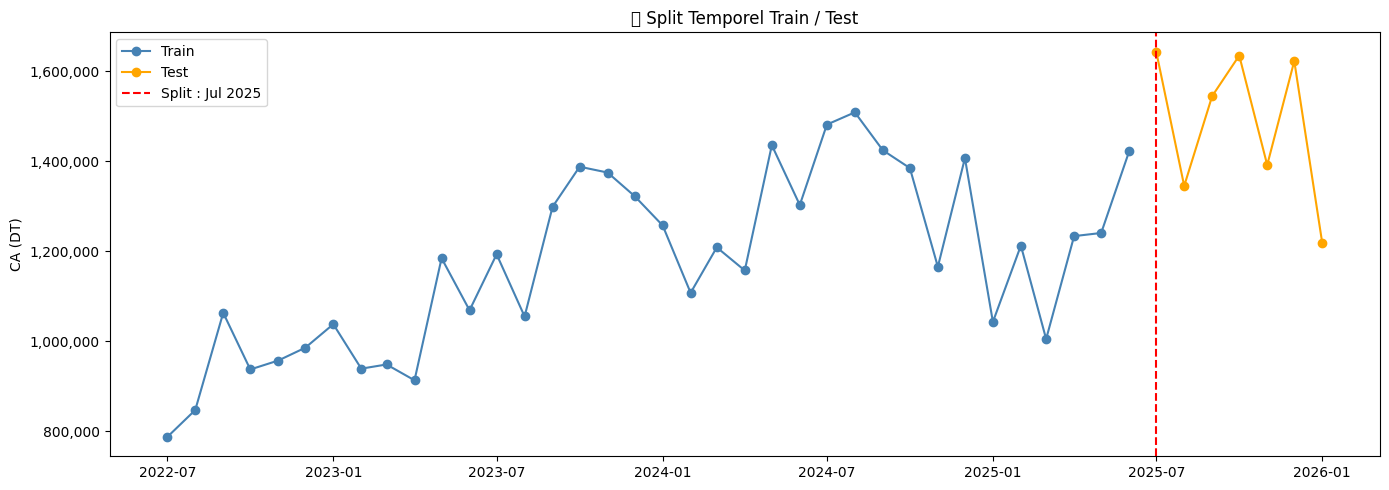

In [31]:
split_idx  = int(len(df_ml) * 0.85)
split_date = df_ml.iloc[split_idx]['date']

X = df_ml[FEATURES_FINAL]
y = df_ml[TARGET]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {len(X_train)} mois ({df_train["date"].min().strftime("%b %Y")} → {df_train["date"].max().strftime("%b %Y")})')
print(f'Test  : {len(X_test)} mois ({df_test["date"].min().strftime("%b %Y")} → {df_test["date"].max().strftime("%b %Y")})')

fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--', label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Comparaison des modèles

In [32]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    mae   = mean_absolute_error(y_te, pred)
    rmse  = np.sqrt(mean_squared_error(y_te, pred))
    r2    = r2_score(y_te, pred)
    mape  = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) / (np.abs(y_te) + np.abs(pred))) * 100
    bias  = np.mean(pred - y_te)
    return {'name': name, 'model': model, 'pred': pred,
            'MAE': mae, 'RMSE': rmse, 'R²': r2,
            'MAPE': mape, 'SMAPE': smape, 'Biais': bias}

models_config = [
    ('LinearRegression', LinearRegression(),                                                       X_train_sc, X_test_sc),
    ('Ridge',            Ridge(alpha=10),                                                          X_train_sc, X_test_sc),
    ('DecisionTree',     DecisionTreeRegressor(max_depth=3, random_state=42),                     X_train,    X_test),
    ('RandomForest',     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),   X_train,    X_test),
    ('XGBoost',          XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, random_state=42), X_train, X_test),
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print('=' * 85)
print(f'{"Modèle":<20} {"MAE":>10} {"RMSE":>10} {"R²":>8} {"MAPE":>8} {"SMAPE":>8} {"Biais":>12}')
print('=' * 85)
for _, row in df_results.iterrows():
    print(f'{row.name:<20} {row["MAE"]:>10,.0f} {row["RMSE"]:>10,.0f} '
          f'{row["R²"]:>8.4f} {row["MAPE"]:>7.2f}% {row["SMAPE"]:>7.2f}% {row["Biais"]:>12,.0f}')
print('=' * 85)

best_name = df_results['MAPE'].idxmin()
print(f'\n🏆 Meilleur modèle : {best_name} (MAPE={df_results.loc[best_name, "MAPE"]:.2f}%)')

Modèle                      MAE       RMSE       R²     MAPE    SMAPE        Biais
LinearRegression         82,428     86,881   0.6889    5.66%    5.64%       -9,368
Ridge                   111,187    127,081   0.3345    7.41%    7.55%      -49,987
DecisionTree            119,733    127,629   0.3287    7.89%    8.25%     -119,733
RandomForest            124,625    139,015   0.2036    8.21%    8.47%      -85,509
XGBoost                 147,380    153,878   0.0242    9.95%   10.22%      -96,994

🏆 Meilleur modèle : LinearRegression (MAPE=5.66%)


## 4. Détail mois par mois — meilleur modèle

=== Détail LinearRegression ===

      date         reel       predit       ecart  ecart%
2025-07-01 1,644,113.02 1,520,898.86 -123,214.16   -7.49
2025-08-01 1,345,444.27 1,391,857.34   46,413.07    3.45
2025-09-01 1,545,185.37 1,467,529.29  -77,656.09   -5.03
2025-10-01 1,635,378.39 1,575,410.35  -59,968.04   -3.67
2025-11-01 1,391,948.18 1,483,965.40   92,017.22    6.61
2025-12-01 1,623,158.26 1,562,709.69  -60,448.57   -3.72
2026-01-01 1,218,358.52 1,335,635.68  117,277.16    9.63

Biais : -9,368.49 DT  (sous-estimation)


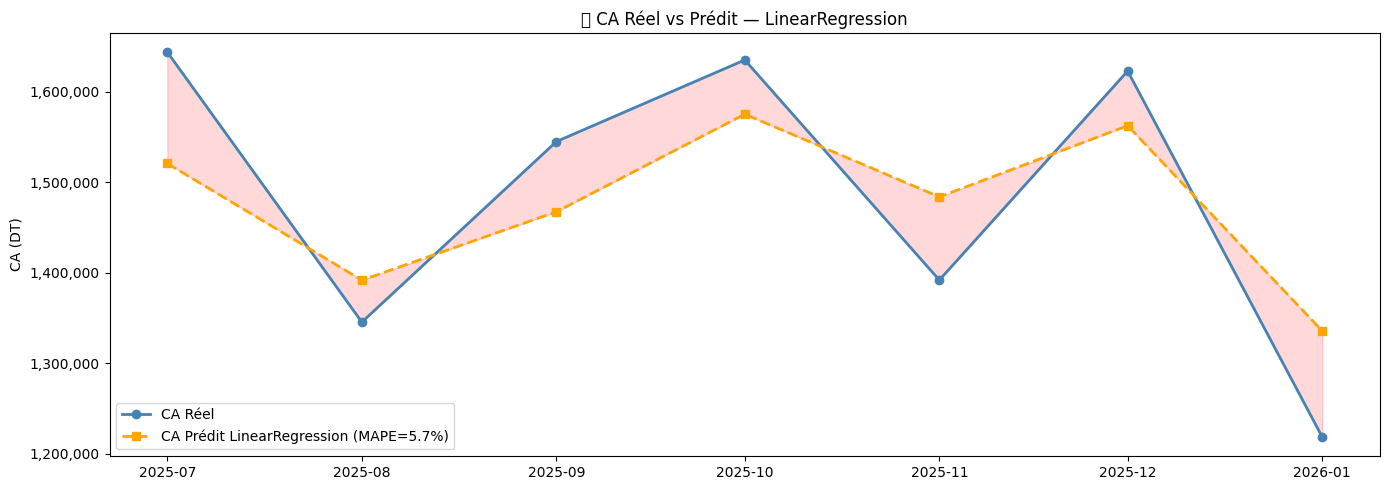

In [33]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f'=== Détail {best_name} ===\n')
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

fig, ax = plt.subplots()
ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='steelblue', marker='o', linewidth=2)
ax.plot(df_test['date'], best['pred'],
        label=f'CA Prédit {best_name} (MAPE={best["MAPE"]:.1f}%)',
        color='orange', marker='s', linestyle='--', linewidth=2)
ax.fill_between(df_test['date'], y_test.values, best['pred'], alpha=0.15, color='red')
ax.set_title(f'📈 CA Réel vs Prédit — {best_name}')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 5. Feature Importance

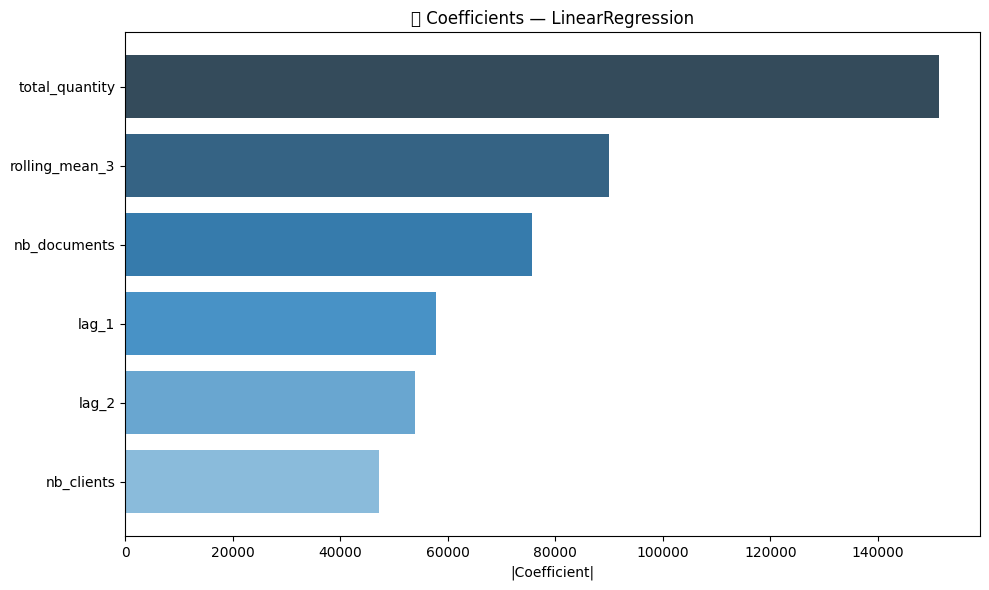

In [34]:
best_model_obj = df_results.loc[best_name, 'model']
use_scaler     = best_name in ['LinearRegression', 'Ridge']

if hasattr(best_model_obj, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature':    FEATURES_FINAL,
        'importance': best_model_obj.feature_importances_
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance['feature'], importance['importance'],
            color=sns.color_palette('Blues_d', len(importance)))
    ax.set_title(f'🔍 Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

elif hasattr(best_model_obj, 'coef_'):
    coef = pd.DataFrame({
        'feature': FEATURES_FINAL,
        'coef':    abs(best_model_obj.coef_)
    }).sort_values('coef', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(coef['feature'], coef['coef'],
            color=sns.color_palette('Blues_d', len(coef)))
    ax.set_title(f'🔍 Coefficients — {best_name}')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## 6. Réentraîner sur tout le dataset + Sauvegarde

In [35]:
print(f'Réentraînement sur {len(df_ml)} mois complets...')

X_full = df_ml[FEATURES_FINAL]
y_full = df_ml[TARGET]

scaler_final = StandardScaler()

if use_scaler:
    X_full_sc   = scaler_final.fit_transform(X_full)
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X_full_sc, y_full)
else:
    model_final = type(best_model_obj)(**best_model_obj.get_params())
    model_final.fit(X_full, y_full)
    scaler_final = scaler

# Sauvegarder
joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

# Moyennes des contemporaines pour la prédiction future
contemporaines_means = {}
for col in CONTEMPORAINES:
    contemporaines_means[col] = float(df_ml[col].tail(6).mean())

config = {
    'best_model':             best_name,
    'use_scaler':             use_scaler,
    'features_final':         FEATURES_FINAL,
    'features_selected':      FEATURES,
    'contemporaines':         CONTEMPORAINES,
    'contemporaines_means':   contemporaines_means,
    'mape_test':              float(best['MAPE']),
    'mae_test':               float(best['MAE']),
    'r2_test':                float(best['R²']),
    'biais_test':             float(best['Biais']),
}

with open('/app/notebooks/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'✅ Modèle final sauvegardé : {best_name}')
print(f'   Entraîné sur : {len(df_ml)} mois')
print(f'   MAPE test    : {best["MAPE"]:.2f}%')
print(f'   MAE test     : {best["MAE"]:,.0f} DT')
print(f'   R² test      : {best["R²"]:.4f}')
print(f'   Biais test   : {best["Biais"]:,.0f} DT')
print(f'\n   Moyennes contemporaines (6 derniers mois) :')
for k, v in contemporaines_means.items():
    print(f'     {k:<20} : {v:,.2f}')

Réentraînement sur 43 mois complets...
✅ Modèle final sauvegardé : LinearRegression
   Entraîné sur : 43 mois
   MAPE test    : 5.66%
   MAE test     : 82,428 DT
   R² test      : 0.6889
   Biais test   : -9,368 DT

   Moyennes contemporaines (6 derniers mois) :
     nb_clients           : 321.83
     nb_documents         : 1,600.83
     total_quantity       : 30,238.50
